In [0]:
print("Databricks Python is working!")

Databricks Python is working!


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [0]:
channel_daily = pd.read_csv("/Volumes/workspace/restaurant_analytics/sales_data/channel_daily.csv")
daily_operations = pd.read_csv("/Volumes/workspace/restaurant_analytics/sales_data/daily_operations.csv")
menu_items= pd.read_csv("/Volumes/workspace/restaurant_analytics/sales_data/menu_items.csv")
item_monthly_sales = pd.read_csv("/Volumes/workspace/restaurant_analytics/sales_data/item_monthly_sales.csv")
branches = pd.read_csv("/Volumes/workspace/restaurant_analytics/sales_data/branches.csv")


### Data Quality Check

In [0]:
print("null values\n",branches.isna().sum())
print("\nnull_values\n",channel_daily.isna().sum())
print("\nnull_values\n",daily_operations.isna().sum())
print("\nnull_values\n",item_monthly_sales.isna().sum())
print("\nnull_values\n",menu_items.isna().sum())

null values
 branch_id           0
branch_name         0
emirate             0
area                0
concept             0
seats               0
has_drive_thru      0
offers_delivery     0
opened_date         0
monthly_rent_aed    0
dtype: int64

null_values
 channel_sales_id             0
branch_id                    0
business_date                0
business_month               0
day_of_week                  0
is_weekend                   0
order_channel                0
orders_count                 0
covers                       0
gross_sales_aed              0
discounts_aed                0
net_sales_aed                0
service_charge_aed           0
vat_aed                      0
total_billed_aed             0
aggregator_commission_aed    0
net_revenue_aed              0
food_cost_aed                0
avg_prep_minutes             0
avg_review_score             0
currency                     0
dtype: int64

null_values
 summary_id                   0
branch_id                    0


No null records were found in the five datasets.

In [0]:
print("branches duplicate values:", branches.duplicated().sum())
print("channel_daily duplicate values:", channel_daily.duplicated().sum())
print("daily_operations duplicate values:", daily_operations.duplicated().sum())
print("item_monthly_sales duplicate values:", item_monthly_sales.duplicated().sum())
print("menu_items duplicate values:", menu_items.duplicated().sum())

branches duplicate values: 0
channel_daily duplicate values: 0
daily_operations duplicate values: 0
item_monthly_sales duplicate values: 0
menu_items duplicate values: 0


No duplicate records were found in the five datasets.

In [0]:
print('\nbranches data_type\n',branches.dtypes)
print('\nchannel_daily data_type\n',channel_daily.dtypes)
print('\ndaily_operations data_type\n',daily_operations.dtypes)
print('\nitem_monthly_sales data_type\n',item_monthly_sales.dtypes)
print('\nmenu_items data_type\n',menu_items.dtypes)


branches data_type
 branch_id           object
branch_name         object
emirate             object
area                object
concept             object
seats                int64
has_drive_thru      object
offers_delivery     object
opened_date         object
monthly_rent_aed     int64
dtype: object

channel_daily data_type
 channel_sales_id              object
branch_id                     object
business_date                 object
business_month                object
day_of_week                   object
is_weekend                    object
order_channel                 object
orders_count                   int64
covers                         int64
gross_sales_aed              float64
discounts_aed                float64
net_sales_aed                float64
service_charge_aed           float64
vat_aed                      float64
total_billed_aed             float64
aggregator_commission_aed    float64
net_revenue_aed              float64
food_cost_aed                float64
avg

In [0]:
branches['opened_date'] = pd.to_datetime(branches['opened_date'], format = '%d-%m-%Y')
channel_daily['business_date'] = pd.to_datetime(channel_daily['business_date'], format = '%d-%m-%Y')
daily_operations['business_date'] = pd.to_datetime(daily_operations['business_date'], format = '%d-%m-%Y')
menu_items['launched_date'] = pd.to_datetime(menu_items['launched_date'], format = '%d-%m-%Y')


In [0]:
channel_daily['Year']=channel_daily['business_date'].dt.year
channel_daily['Month']=channel_daily['business_date'].dt.month


In [0]:
daily_operations['Year']=daily_operations['business_date'].dt.year
daily_operations['Month']=daily_operations['business_date'].dt.month


In [0]:
item_monthly_sales['Year']=item_monthly_sales['business_month'].str.split('-').str[0].astype(int)
item_monthly_sales['Month']=item_monthly_sales['business_month'].str.split('-').str[1].astype(int)


In [0]:
print("Branches:\n",branches.describe())
print("\nChannel Daily:\n",channel_daily.describe())
print("\nDaily Operations:\n",daily_operations.describe())
print("\nItem Monthly Sales:\n",item_monthly_sales.describe())
print("\nMenu Items:\n",menu_items.describe())

Branches:
             seats          opened_date  monthly_rent_aed
count   18.000000                   18         18.000000
mean    72.666667  2020-01-29 18:40:00     118200.000000
min     38.000000  2016-04-21 00:00:00      56900.000000
25%     52.750000  2018-10-12 12:00:00      74275.000000
50%     72.500000  2020-02-23 00:00:00      94700.000000
75%     88.750000  2021-11-23 00:00:00     162200.000000
max    120.000000  2023-03-31 00:00:00     248400.000000
std     24.511702                  NaN      56764.135322

Channel Daily:
              business_date  orders_count  ...          Year         Month
count                67488  67488.000000  ...  67488.000000  67488.000000
mean   2025-03-31 12:00:00     28.758268  ...   2024.797149      5.922149
min    2024-01-01 00:00:00      3.000000  ...   2024.000000      1.000000
25%    2024-08-15 18:00:00     13.000000  ...   2024.000000      3.000000
50%    2025-03-31 12:00:00     22.000000  ...   2025.000000      6.000000
75%    2025-11-

## EDA

In [0]:
channel_daily[['gross_sales_aed','net_sales_aed','discounts_aed','aggregator_commission_aed','net_revenue_aed','food_cost_aed']].min()

gross_sales_aed              67.00
net_sales_aed                58.92
discounts_aed                 0.00
aggregator_commission_aed     0.00
net_revenue_aed              58.92
food_cost_aed                14.07
dtype: float64

In [0]:
daily_operations[['net_sales_aed','discounts_aed','net_revenue_aed','food_cost_aed','waste_cost_aed','labour_cost_aed']].min()

net_sales_aed      4866.58
discounts_aed         1.40
net_revenue_aed    4602.93
food_cost_aed      1424.92
waste_cost_aed       14.41
labour_cost_aed     286.98
dtype: float64

In [0]:
item_monthly_sales[['gross_sales_aed','food_cost_aed','gross_margin_aed','quantity_sold']].min()

gross_sales_aed     456.50
food_cost_aed        83.14
gross_margin_aed    363.65
quantity_sold        62.00
dtype: float64

In [0]:
menu_items[['item_cost_aed','menu_price_aed','calories','prep_minutes']].min()

item_cost_aed      1.81
menu_price_aed    10.00
calories          96.00
prep_minutes       1.00
dtype: float64

There are no negative value in all 5 tables

In [0]:
print('channel_type:', channel_daily['order_channel'].unique())

print('\nmenu_category:', menu_items['menu_category'].unique())

print('\nis_vegetarian:', menu_items['is_vegetarian'].unique())

print('\nis_active:', menu_items['is_active'].unique())

print('\nemirate:', branches['emirate'].unique())

print('\narea:', branches['area'].unique())

print('\nconcept:', branches['concept'].unique())

channel_type: ['Dine-in' 'Takeaway' 'Aggregator Delivery' 'Own Delivery' 'Drive-Thru']

menu_category: ['Appetizers' 'Mains' 'Grills' 'Sandwiches' 'Sides' 'Desserts'
 'Hot Drinks' 'Cold Drinks']

is_vegetarian: ['Yes' 'No']

is_active: ['Yes' 'No']

emirate: ['Dubai' 'Abu Dhabi' 'Sharjah' 'Ajman' 'Ras Al Khaimah' 'Fujairah'
 'Al Ain']

area: ['Dubai Marina' 'Downtown Dubai' 'Al Barsha' 'Jumeirah' 'Business Bay'
 'Deira' 'Dubai Silicon Oasis' 'Corniche' 'Yas Island' 'Al Khalidiyah'
 'Al Raha' 'Mussafah' 'Al Majaz' 'Al Wahda' 'Al Nakheel' 'Al Faseel'
 'Central District']

concept: ['Casual Dining' 'Fine Dining' 'Quick Service' 'Café']


Categorical data looks consistent and there are no spelling variations or unexpected values

### Final Data Cleaning Check

In [0]:
print("BRANCHES")
print(branches.isna().sum().sum(), "missing values")
print(branches.duplicated().sum(), "duplicate rows")

print("\nCHANNEL DAILY")
print(channel_daily.isna().sum().sum(), "missing values")
print(channel_daily.duplicated().sum(), "duplicate rows")

print("\nDAILY OPERATIONS")
print(daily_operations.isna().sum().sum(), "missing values")
print(daily_operations.duplicated().sum(), "duplicate rows")

print("\nITEM MONTHLY SALES")
print(item_monthly_sales.isna().sum().sum(), "missing values")
print(item_monthly_sales.duplicated().sum(), "duplicate rows")

print("\nMENU ITEMS")
print(menu_items.isna().sum().sum(), "missing values")
print(menu_items.duplicated().sum(), "duplicate rows")

BRANCHES
0 missing values
0 duplicate rows

CHANNEL DAILY
0 missing values
0 duplicate rows

DAILY OPERATIONS
0 missing values
0 duplicate rows

ITEM MONTHLY SALES
0 missing values
0 duplicate rows

MENU ITEMS
0 missing values
0 duplicate rows


Monthly Revenue Trend

In [0]:
monthly_revenue =  (
                    daily_operations.groupby(['Year', 'Month'])['net_revenue_aed'].sum().reset_index().sort_values(['Year', 'Month']) )

In [0]:
monthly_revenue['Year_Month'] = pd.to_datetime(monthly_revenue['Year'].astype(str) + '-' + monthly_revenue['Month'].astype(str))

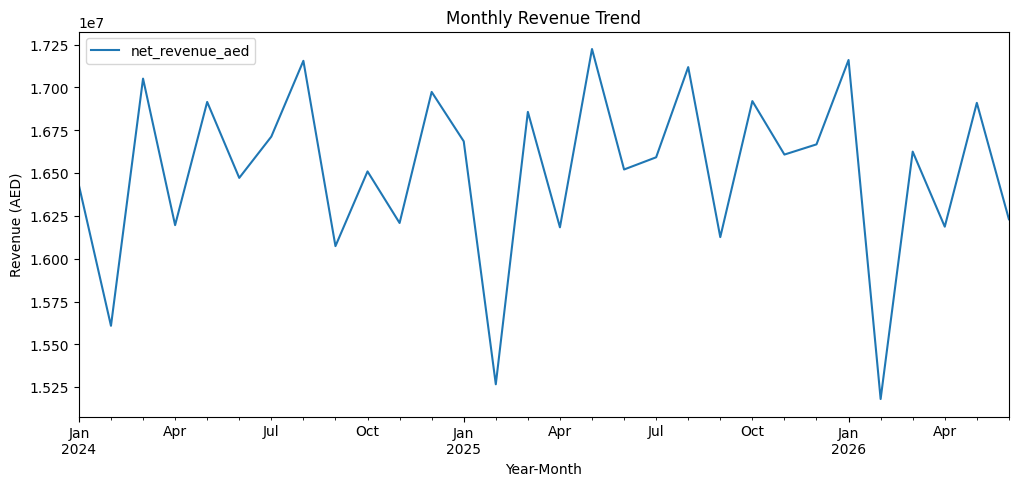

In [0]:
monthly_revenue.plot(
    x='Year_Month',
    y='net_revenue_aed',
    kind='line',
    figsize=(12,5)
)
plt.title("Monthly Revenue Trend")
plt.xlabel('Year-Month')
plt.ylabel('Revenue (AED)')
plt.show()


In [0]:
Monthly_orders = (
            daily_operations.groupby(['Year', 'Month'])['orders_count'].sum().reset_index().sort_values(['Year', 'Month']))

In [0]:
Monthly_orders['Year_Month']=pd.to_datetime(Monthly_orders['Year'].astype(str) + '-' + Monthly_orders['Month'].astype(str))

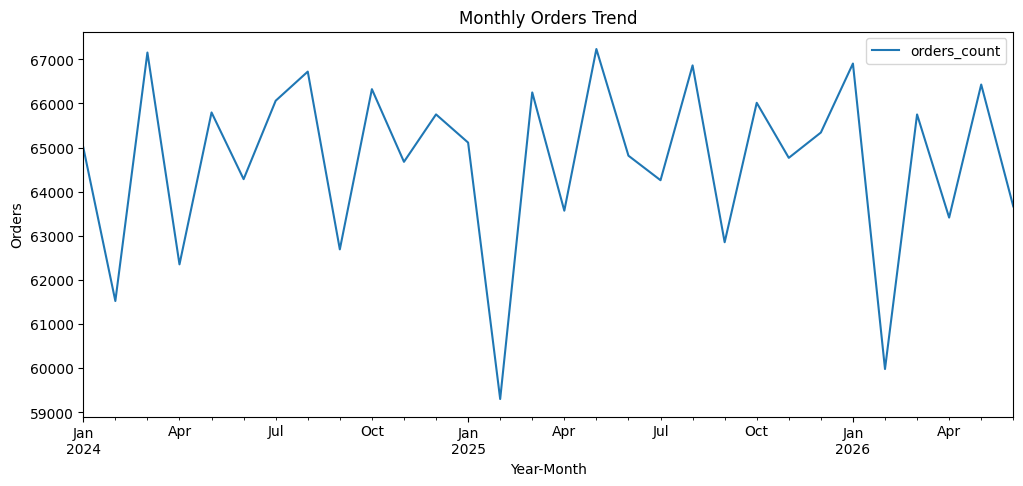

In [0]:
Monthly_orders.plot(
    x='Year_Month',
    y='orders_count',
    kind='line',
    figsize=(12,5)
)
plt.title("Monthly Orders Trend")
plt.xlabel('Year-Month')
plt.ylabel('Orders')
plt.show()

Monthly Revenue by Branch

In [0]:
monthly_branch_revenue = (
    daily_operations.merge(branches, how='left', on='branch_id').groupby(['branch_name', 'Year', 'Month'])['net_revenue_aed'].sum().reset_index().sort_values(['Year', 'Month']))

In [0]:
monthly_branch_revenue['Year_Month']= pd.to_datetime(monthly_branch_revenue['Year'].astype(str) + '-' + monthly_branch_revenue['Month'].astype(str))

In [0]:
branch_revenue = (
    daily_operations.merge(branches, how='left', on='branch_id').groupby(['branch_name'])['net_revenue_aed'].sum().reset_index().sort_values('net_revenue_aed', ascending=False))


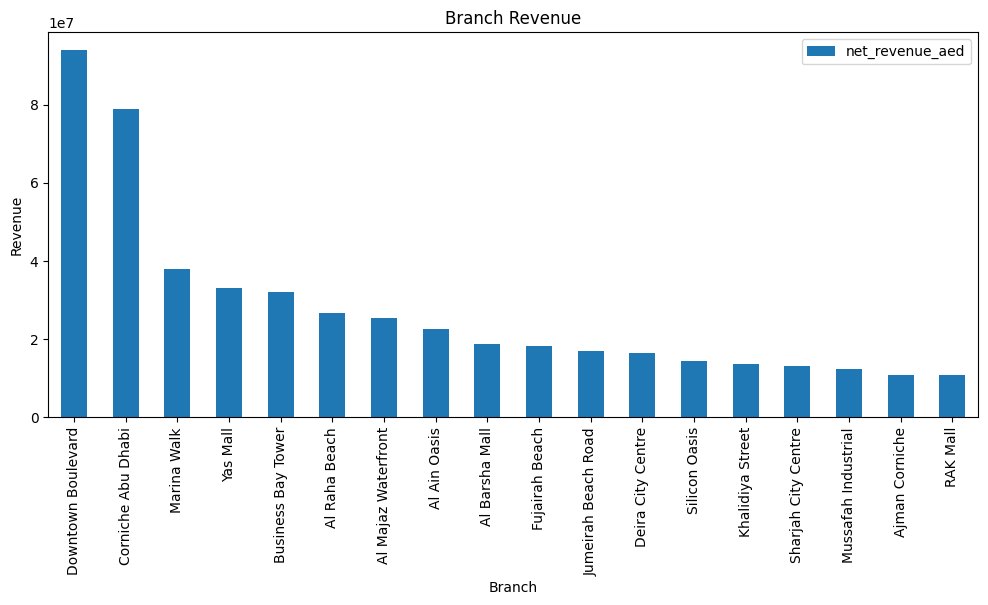

In [0]:
branch_revenue.plot(
    x='branch_name',
    y='net_revenue_aed',
    kind='bar',
    figsize=(12,5)
)
plt.title("Branch Revenue")
plt.xlabel('Branch')
plt.ylabel('Revenue')
plt.show()


Revenue by Order Channel

In [0]:
channel_wise_revenue = (
    channel_daily.groupby('order_channel')['net_revenue_aed'].sum().reset_index().sort_values('net_revenue_aed', ascending=False))

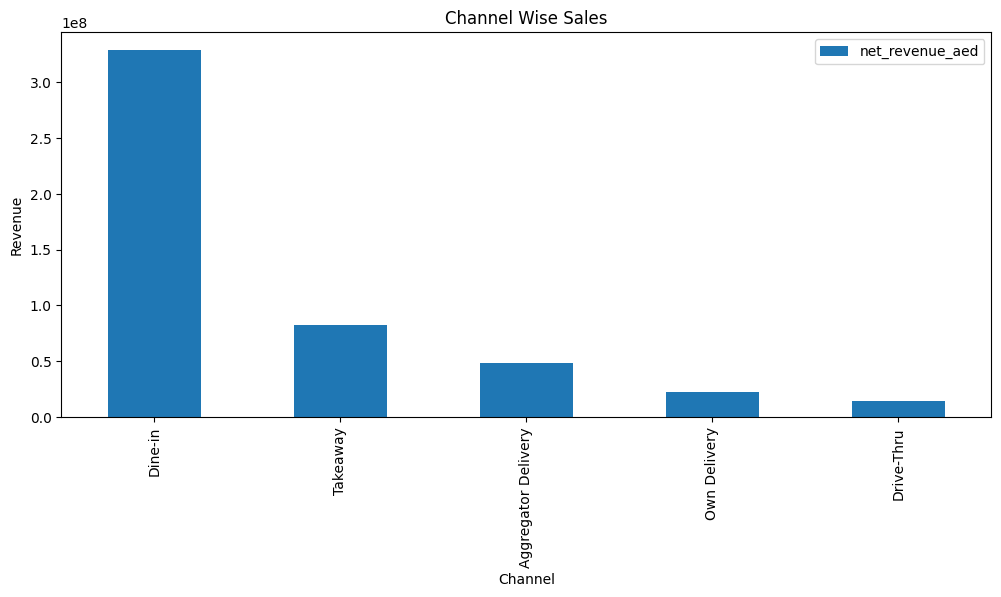

In [0]:
channel_wise_revenue.plot(
    x='order_channel',
    y='net_revenue_aed',
    kind='bar',
    figsize=(12,5)
)
plt.title("Channel Wise Sales")
plt.xlabel('Channel')
plt.ylabel('Revenue')
plt.show()

Revenue by Menu Category

In [0]:
category_quantity = item_monthly_sales.merge(menu_items, how='left', on='item_id').groupby('menu_category_x')['quantity_sold'].sum().reset_index().sort_values( 'quantity_sold', ascending = False).reset_index(drop=True)

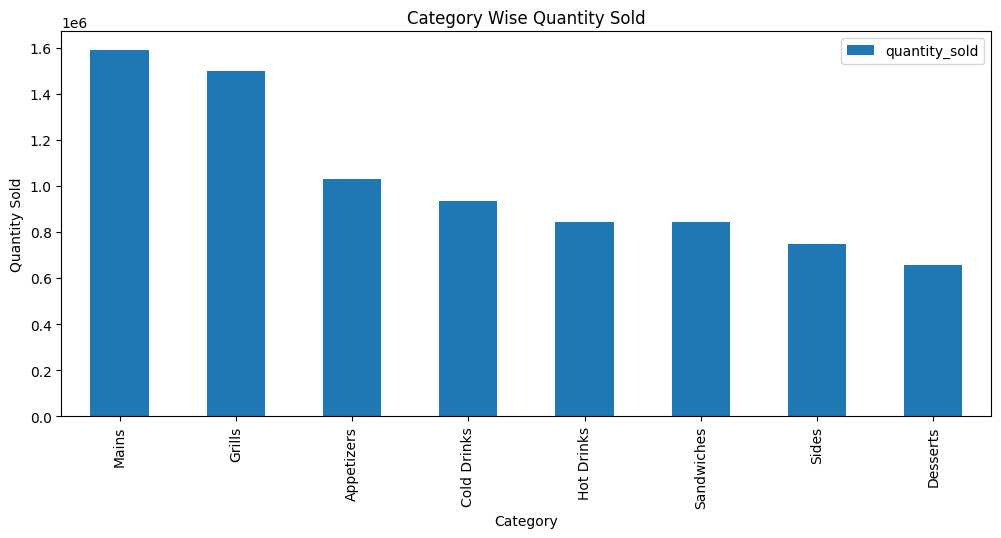

In [0]:
category_quantity.plot(
    x='menu_category_x',
    y='quantity_sold',
    kind='bar',
    figsize=(12,5)
)
plt.title("Category Wise Quantity Sold")
plt.xlabel('Category')
plt.ylabel('Quantity Sold')
plt.show()

Revenue by Menu Category

In [0]:
gross_sales_by_category = item_monthly_sales.merge(menu_items, how='left', on='item_id').groupby('menu_category_x')['gross_sales_aed'].sum().reset_index().sort_values( 'gross_sales_aed', ascending = False).reset_index(drop=True)

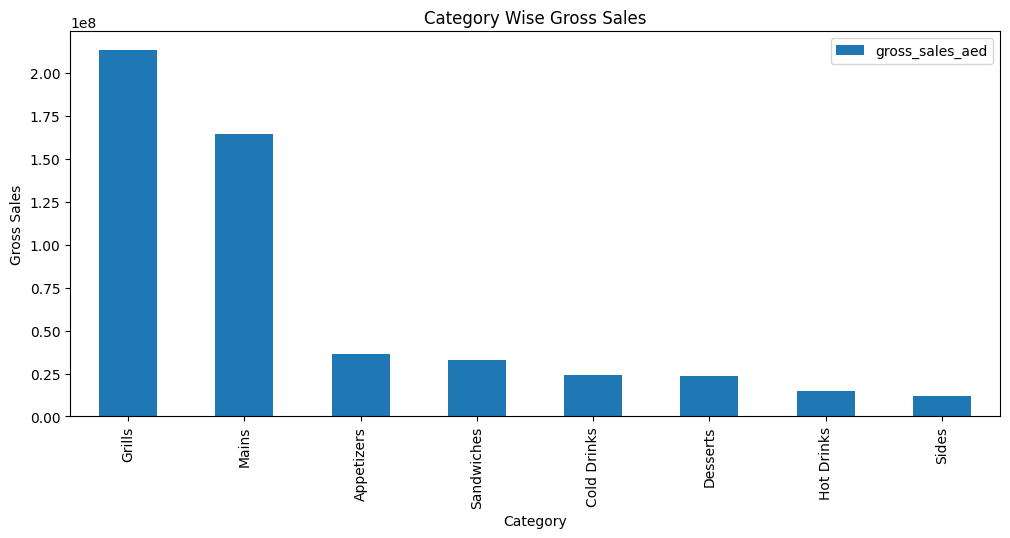

In [0]:
gross_sales_by_category.plot(
    x='menu_category_x',
    y='gross_sales_aed',
    kind='bar',
    figsize=(12,5)
)
plt.title("Category Wise Gross Sales")
plt.xlabel('Category')
plt.ylabel('Gross Sales')
plt.show()

Weekend vs Weekday Performance

In [0]:
channel_daily.columns

Index(['channel_sales_id', 'branch_id', 'business_date', 'business_month',
       'day_of_week', 'is_weekend', 'order_channel', 'orders_count', 'covers',
       'gross_sales_aed', 'discounts_aed', 'net_sales_aed',
       'service_charge_aed', 'vat_aed', 'total_billed_aed',
       'aggregator_commission_aed', 'net_revenue_aed', 'food_cost_aed',
       'avg_prep_minutes', 'avg_review_score', 'currency', 'Year', 'Month'],
      dtype='object')

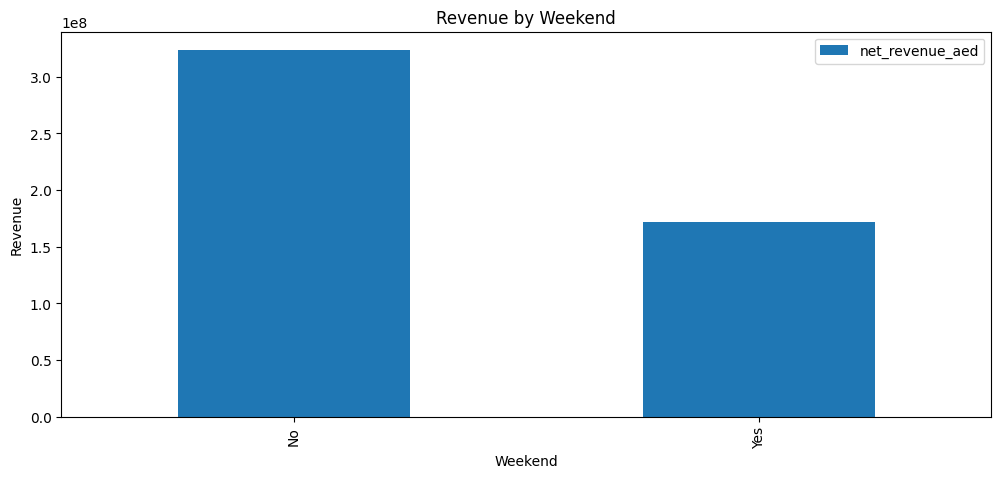

In [0]:
channel_daily.groupby("is_weekend")['net_revenue_aed'].sum().reset_index().sort_values('net_revenue_aed', ascending = False).plot(
    x="is_weekend",
    y="net_revenue_aed",
    kind="bar",
    figsize=(12,5)
)
plt.title("Revenue by Weekend")
plt.xlabel('Weekend')
plt.ylabel('Revenue')
plt.show()

In [0]:
revenue_food = daily_operations[
    ['net_revenue_aed', 'food_cost_aed']
]

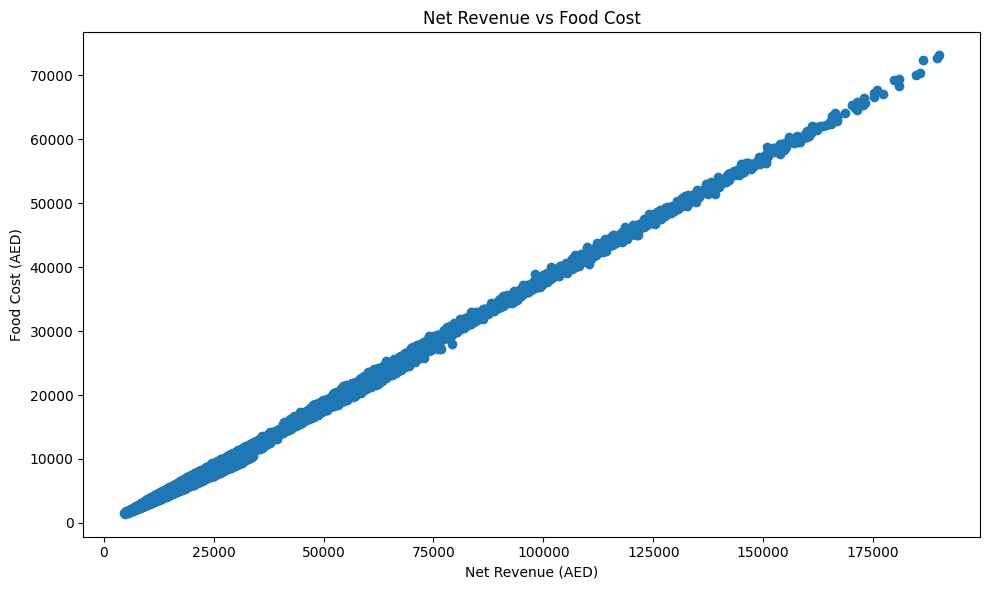

In [0]:
plt.figure(figsize=(10, 6))

plt.scatter(
    revenue_food['net_revenue_aed'],
    revenue_food['food_cost_aed']
)

plt.title('Net Revenue vs Food Cost')
plt.xlabel('Net Revenue (AED)')
plt.ylabel('Food Cost (AED)')

plt.tight_layout()
plt.show()

Prime Cost % by Branch

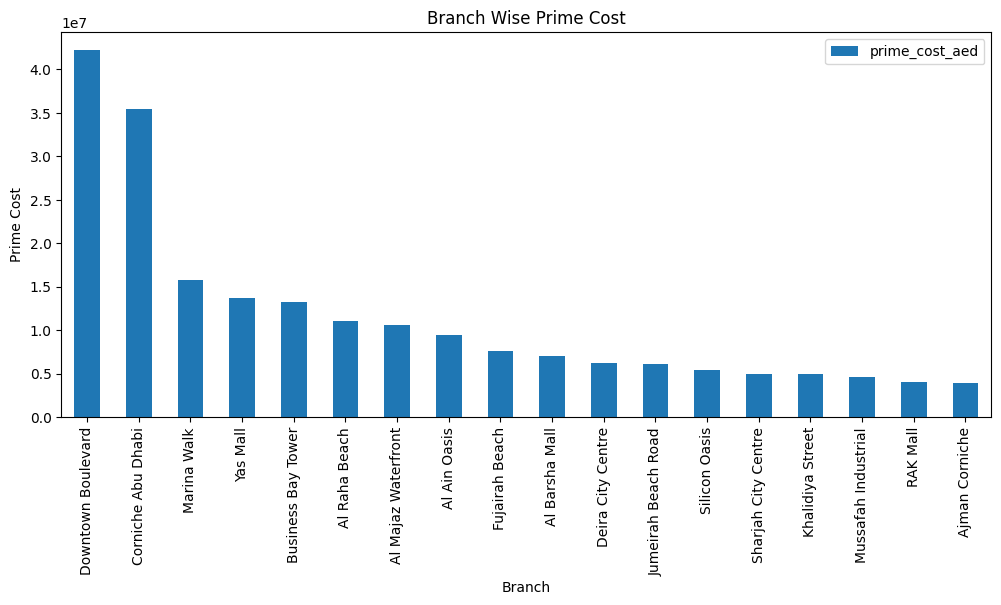

In [0]:
daily_operations.merge(branches,how='left',on='branch_id').groupby('branch_name')['prime_cost_aed'].sum().reset_index().sort_values('prime_cost_aed', ascending = False).plot(
    x='branch_name',
    y='prime_cost_aed',
    kind='bar',
    figsize=(12,5)
)
plt.title("Branch Wise Prime Cost")
plt.xlabel('Branch')
plt.ylabel('Prime Cost')
plt.show()

In [0]:
daily_operations['prime_cost_aed'] = (
    daily_operations['food_cost_aed']
    + daily_operations['labour_cost_aed']
)

In [0]:
daily_operations['prime_cost_pct'] = (
    daily_operations['prime_cost_aed']
    / daily_operations['net_revenue_aed']
    * 100
)

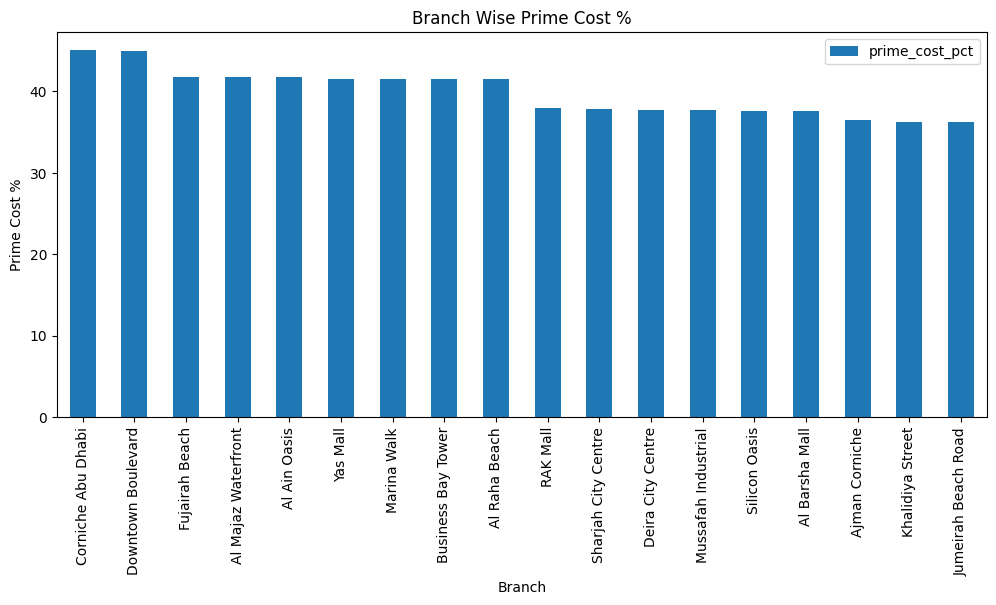

In [0]:
daily_operations.merge(branches,how='left',on='branch_id').groupby('branch_name')['prime_cost_pct'].mean().reset_index().sort_values('prime_cost_pct', ascending = False).plot(
    x='branch_name',
    y='prime_cost_pct',
    kind='bar',
    figsize=(12,5)
)
plt.title("Branch Wise Prime Cost %")
plt.xlabel('Branch')
plt.ylabel('Prime Cost %')
plt.show()

In [0]:
daily_operations.columns

Index(['summary_id', 'branch_id', 'business_date', 'business_month',
       'day_of_week', 'is_weekend', 'orders_count', 'covers', 'net_sales_aed',
       'discounts_aed', 'aggregator_commission_aed', 'net_revenue_aed',
       'food_cost_aed', 'waste_cost_aed', 'labour_hours', 'labour_cost_aed',
       'prime_cost_pct', 'avg_review_score', 'currency', 'Year', 'Month',
       'prime_cost_aed'],
      dtype='object')

In [0]:
monthly_revenue = daily_operations.groupby('business_month')['net_revenue_aed'].sum().reset_index())

In [0]:
each_month_revenue = monthly_revenue.sort_values(
    'Year_Month'
).reset_index(drop=True)

In [0]:
each_month_revenue['month_number'] =range(1,len(each_month_revenue)+1)

In [0]:
each_month_revenue['time_index'] = range(
    1,
    len(each_month_revenue) + 1
)

Predictive Analysis

## Regression Modeling

The objective is to predict restaurant revenue using branch, channel, menu, and operational features.

In [0]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [0]:
branches.columns

Index(['branch_id', 'branch_name', 'emirate', 'area', 'concept', 'seats',
       'has_drive_thru', 'offers_delivery', 'opened_date', 'monthly_rent_aed'],
      dtype='object')

In [0]:
daily_operations.columns

Index(['summary_id', 'branch_id', 'business_date', 'business_month',
       'day_of_week', 'is_weekend', 'orders_count', 'covers', 'net_sales_aed',
       'discounts_aed', 'aggregator_commission_aed', 'net_revenue_aed',
       'food_cost_aed', 'waste_cost_aed', 'labour_hours', 'labour_cost_aed',
       'prime_cost_pct', 'avg_review_score', 'currency', 'Year', 'Month',
       'prime_cost_aed'],
      dtype='object')

In [0]:
menu_items.columns

Index(['item_id', 'item_name', 'menu_category', 'menu_price_aed',
       'item_cost_aed', 'prep_minutes', 'is_vegetarian', 'calories',
       'is_active', 'launched_date'],
      dtype='object')

In [0]:
item_monthly_sales.columns

Index(['item_sales_id', 'branch_id', 'business_month', 'item_id',
       'menu_category', 'quantity_sold', 'gross_sales_aed', 'food_cost_aed',
       'gross_margin_aed', 'currency', 'Year', 'Month'],
      dtype='object')

In [0]:
branches_ml = branches.copy()

channel_ml = channel_daily.copy()

operations_ml = daily_operations.copy()

item_sales_ml = item_monthly_sales.copy()

menu_ml = menu_items.copy()

In [0]:
print(branches_ml.shape)
print(channel_ml.shape)
print(operations_ml.shape)
print(item_sales_ml.shape)
print(menu_ml.shape)

(18, 10)
(67488, 23)
(16416, 22)
(46980, 12)
(98, 10)


### Feature Selection

Selected business and operational features were used as inputs for the regression model, while revenue was used as the target variable.

In [0]:
features = [
    # Branch factors
    'emirate',
    'concept',
    'seats',
    'has_drive_thru',
    'offers_delivery',

    # Channel factors
    'order_channel',
    'orders_count',
    'covers',
    'discounts_aed',
    'avg_prep_minutes',
    'avg_review_score',

    # Operations factors
    'waste_cost_aed',
    'labour_hours',
    'labour_cost_aed',

    # Menu factors
    'menu_price_aed',
    'item_cost_aed',
    'prep_minutes',
    'is_vegetarian'
]

target = 'net_revenue_aed'

In [0]:
operations_ml = operations_ml.merge(branches_ml[
        ['branch_id','emirate','concept','seats','has_drive_thru','offers_delivery']],on='branch_id',how='left')

In [0]:
channel_features = (channel_ml.groupby(['branch_id', 'business_date']).agg(
        channel_orders=('orders_count', 'sum'),
        channel_covers=('covers', 'sum'),
        channel_discounts=('discounts_aed', 'sum'),
        avg_prep_minutes=('avg_prep_minutes', 'mean'),
        avg_review_score=('avg_review_score', 'mean')
    )
    .reset_index()
)

In [0]:
operations_ml = operations_ml.merge(channel_features,on=['branch_id', 'business_date'],how='left')

In [0]:
item_features = (item_sales_ml.groupby(['branch_id', 'business_month']).agg(
        total_quantity_sold=('quantity_sold', 'sum'),
        total_item_sales=('gross_sales_aed', 'sum'),
        total_item_margin=('gross_margin_aed', 'sum')
    )
    .reset_index()
)

In [0]:
operations_ml['business_month'] = pd.to_datetime(
    operations_ml['business_month'],
    format='%Y-%m'
)

In [0]:
item_features['business_month'] = pd.to_datetime(
    item_features['business_month'],
    format='%Y-%m'
)

In [0]:
operations_ml = operations_ml.merge(
    item_features,
    on=['branch_id', 'business_month'],
    how='left'
)

In [0]:
item_menu = item_sales_ml.merge(
    menu_ml[
        [
            'item_id',
            'menu_price_aed',
            'item_cost_aed',
            'prep_minutes',
            'is_vegetarian'
        ]
    ],
    on='item_id',
    how='left'
)

In [0]:
item_menu['menu_price_aed'] = pd.to_numeric(
    item_menu['menu_price_aed'],
    errors='coerce'
)

item_menu['item_cost_aed'] = pd.to_numeric(
    item_menu['item_cost_aed'],
    errors='coerce'
)

item_menu['prep_minutes'] = pd.to_numeric(
    item_menu['prep_minutes'],
    errors='coerce'
)

item_menu['is_vegetarian'] = (
    item_menu['is_vegetarian']
    .map({'Yes': 1, 'No': 0})
)

In [0]:
menu_features = (
    item_menu
    .groupby(['branch_id', 'business_month'])
    .agg(
        avg_menu_price=('menu_price_aed', 'mean'),
        avg_item_cost=('item_cost_aed', 'mean'),
        avg_prep_minutes=('prep_minutes', 'mean'),
        vegetarian_item_ratio=('is_vegetarian', 'mean')
    )
    .reset_index()
)

In [0]:
menu_features['business_month'] = pd.to_datetime(
    menu_features['business_month'],
    format='%Y-%m'
)

In [0]:
operations_ml = operations_ml.merge(
    menu_features,
    on=['branch_id', 'business_month'],
    how='left'
)

In [0]:
operations_ml.shape

(16416, 39)

In [0]:
operations_ml.columns.tolist()

['summary_id',
 'branch_id',
 'business_date',
 'business_month',
 'day_of_week',
 'is_weekend',
 'orders_count',
 'covers',
 'net_sales_aed',
 'discounts_aed',
 'aggregator_commission_aed',
 'net_revenue_aed',
 'food_cost_aed',
 'waste_cost_aed',
 'labour_hours',
 'labour_cost_aed',
 'prime_cost_pct',
 'avg_review_score_x',
 'currency',
 'Year',
 'Month',
 'prime_cost_aed',
 'emirate',
 'concept',
 'seats',
 'has_drive_thru',
 'offers_delivery',
 'channel_orders',
 'channel_covers',
 'channel_discounts',
 'avg_prep_minutes_x',
 'avg_review_score_y',
 'total_quantity_sold',
 'total_item_sales',
 'total_item_margin',
 'avg_menu_price',
 'avg_item_cost',
 'avg_prep_minutes_y',
 'vegetarian_item_ratio']

In [0]:
operations_ml.head()

,summary_id,branch_id,business_date,business_month,day_of_week,is_weekend,orders_count,covers,net_sales_aed,discounts_aed,aggregator_commission_aed,net_revenue_aed,food_cost_aed,waste_cost_aed,labour_hours,labour_cost_aed,prime_cost_pct,avg_review_score_x,currency,Year,Month,prime_cost_aed,emirate,concept,seats,has_drive_thru,offers_delivery,channel_orders,channel_covers,channel_discounts,avg_prep_minutes_x,avg_review_score_y,total_quantity_sold,total_item_sales,total_item_margin,avg_menu_price,avg_item_cost,avg_prep_minutes_y,vegetarian_item_ratio
0,DAY-000001,BR-01,2024-01-01,2024-01-01,Monday,No,135,250,32705.96,616.04,1399.49,31306.47,11069.52,187.35,78,1924.60,41.506181,4.21,AED,2024,1,12994.12,Dubai,Casual Dining,120,No,Yes,135,250,616.04,14.7675,4.2125,20523,1340317.0,894100.81,65.528736,21.806207,10.057471,0.425287
1,DAY-000002,BR-01,2024-01-02,2024-01-01,Tuesday,No,114,187,32543.09,727.91,1885.73,30657.36,11343.19,459.36,68,1822.62,42.945022,4.28,AED,2024,1,13165.81,Dubai,Casual Dining,120,No,Yes,114,187,727.91,15.0625,4.2775,20523,1340317.0,894100.81,65.528736,21.806207,10.057471,0.425287
2,DAY-000003,BR-01,2024-01-03,2024-01-01,Wednesday,No,121,201,34054.76,550.24,1906.48,32148.28,11715.04,512.34,71,2057.55,42.840830,4.62,AED,2024,1,13772.59,Dubai,Casual Dining,120,No,Yes,121,201,550.24,16.3300,4.6200,20523,1340317.0,894100.81,65.528736,21.806207,10.057471,0.425287
3,DAY-000004,BR-01,2024-01-04,2024-01-01,Thursday,No,157,256,38635.89,859.11,1975.01,36660.88,12998.38,498.79,89,2080.11,41.129646,4.18,AED,2024,1,15078.49,Dubai,Casual Dining,120,No,Yes,157,256,859.11,15.3325,4.1825,20523,1340317.0,894100.81,65.528736,21.806207,10.057471,0.425287
4,DAY-000005,BR-01,2024-01-05,2024-01-01,Friday,No,158,290,42193.85,1197.15,1831.28,40362.57,14705.63,258.37,90,2125.79,41.700566,4.18,AED,2024,1,16831.42,Dubai,Casual Dining,120,No,Yes,158,290,1197.15,14.9200,4.1825,20523,1340317.0,894100.81,65.528736,21.806207,10.057471,0.425287


In [0]:
operations_ml.isna().sum()

summary_id                   0
branch_id                    0
business_date                0
business_month               0
day_of_week                  0
is_weekend                   0
orders_count                 0
covers                       0
net_sales_aed                0
discounts_aed                0
aggregator_commission_aed    0
net_revenue_aed              0
food_cost_aed                0
waste_cost_aed               0
labour_hours                 0
labour_cost_aed              0
prime_cost_pct               0
avg_review_score_x           0
currency                     0
Year                         0
Month                        0
prime_cost_aed               0
emirate                      0
concept                      0
seats                        0
has_drive_thru               0
offers_delivery              0
channel_orders               0
channel_covers               0
channel_discounts            0
avg_prep_minutes_x           0
avg_review_score_y           0
total_qu

In [0]:
model_features = [
    # Branch
    'emirate',
    'concept',
    'seats',
    'has_drive_thru',
    'offers_delivery',

    # Channel / Sales activity
    'channel_orders',
    'channel_covers',
    'channel_discounts',
    'avg_prep_minutes_x',
    'avg_review_score_y',

    # Menu
    'total_quantity_sold',
    'avg_menu_price',
    'avg_item_cost',
    'vegetarian_item_ratio'
]

X = operations_ml[model_features]
y = operations_ml['net_revenue_aed']

In [0]:
X.head()

,emirate,concept,seats,has_drive_thru,offers_delivery,channel_orders,channel_covers,channel_discounts,avg_prep_minutes_x,avg_review_score_y,total_quantity_sold,avg_menu_price,avg_item_cost,vegetarian_item_ratio
0,Dubai,Casual Dining,120,No,Yes,135,250,616.04,14.7675,4.2125,20523,65.528736,21.806207,0.425287
1,Dubai,Casual Dining,120,No,Yes,114,187,727.91,15.0625,4.2775,20523,65.528736,21.806207,0.425287
2,Dubai,Casual Dining,120,No,Yes,121,201,550.24,16.3300,4.6200,20523,65.528736,21.806207,0.425287
3,Dubai,Casual Dining,120,No,Yes,157,256,859.11,15.3325,4.1825,20523,65.528736,21.806207,0.425287
4,Dubai,Casual Dining,120,No,Yes,158,290,1197.15,14.9200,4.1825,20523,65.528736,21.806207,0.425287


In [0]:
y.head()

0    31306.47
1    30657.36
2    32148.28
3    36660.88
4    40362.57
Name: net_revenue_aed, dtype: float64

In [0]:
X_encoded = pd.get_dummies(X,columns=['emirate', 'concept'],drop_first=True)
X_encoded['has_drive_thru'] = (X_encoded['has_drive_thru'].map({'Yes': 1, 'No': 0}))
X_encoded['offers_delivery'] = (X_encoded['offers_delivery'].map({'Yes': 1, 'No': 0}))

### Train-Test Split

The dataset was divided into training and testing sets to evaluate how well the model performs on unseen data.

In [0]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [0]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (13132, 21)
X_test: (3284, 21)
y_train: (13132,)
y_test: (3284,)


In [0]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [0]:
y_pred = model.predict(X_test)

In [0]:
pd.DataFrame({
    'Actual_Revenue': y_test.values,
    'Predicted_Revenue': y_pred
}).head(10)

,Actual_Revenue,Predicted_Revenue
0,20165.39,17652.995362
1,15720.82,15578.023352
2,20222.53,20223.931083
3,18886.27,18866.211785
4,20596.91,17878.252152
5,19693.51,23667.929650
6,31850.83,37251.022241
7,33817.31,33287.252261
8,89208.21,85967.272683
9,8994.68,5634.783130


### Model Evaluation

The model was evaluated using MAE, RMSE, and R² to understand prediction error and overall model performance.

In [0]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 2756.6910019132015
RMSE: 3976.3594577678423
R²: 0.9768279760709815


In [0]:
feature_coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

feature_coefficients.sort_values(
    'Coefficient',
    ascending=False
)

,Feature,Coefficient
19,concept_Fine Dining,1.667673e+04
18,concept_Casual Dining,1.352489e+04
20,concept_Quick Service,7.589505e+03
1,has_drive_thru,7.589505e+03
12,emirate_Ajman,4.466725e+03
6,avg_prep_minutes_x,8.105452e+02
15,emirate_Fujairah,7.397750e+02
17,emirate_Sharjah,3.276466e+02
13,emirate_Al Ain,3.080877e+02
4,channel_covers,1.614832e+02


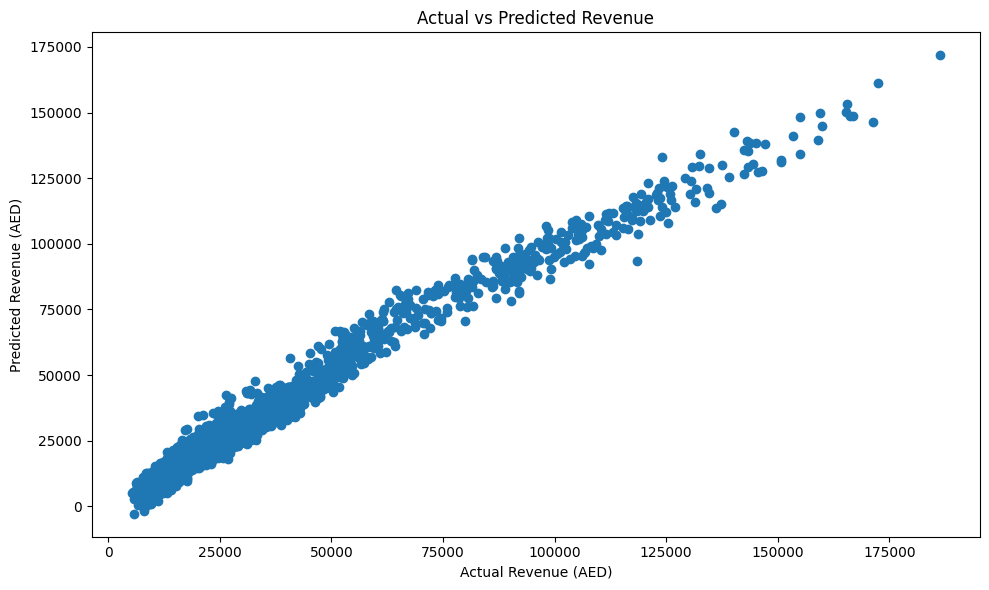

In [0]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Revenue (AED)')
plt.ylabel('Predicted Revenue (AED)')
plt.title('Actual vs Predicted Revenue')

plt.tight_layout()
plt.show()

- The analysis shows that **branch and restaurant-related factors have a strong impact on revenue**, especially things like branch capacity, sales channels, and menu characteristics.
- The model performed well, with an **R² score of 97.68%**, which means the selected factors were able to explain most of the variation in revenue.
- The prediction results also show that **actual and predicted revenue values were quite close**, so the model can be useful for understanding the main factors behind restaurant revenue and supporting business planning.